In [1]:
# Load Model
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    in_channels=1,
    classes=3
)

model.load_state_dict(
    torch.load("../models/liver_best_model.pth", map_location=device)
)

model.to(device)
model.eval()

print("Model Loaded")

d:\Users\Asus\Liver_Tumor_Segmentation_Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model Loaded


In [29]:
# Load Image 
img_path = "../processed_data/val/images/liver_34_100_0.png"   # change image name

img = cv2.imread(img_path, 0)
img = cv2.resize(img, (256,256))

input_img = img / 255.0
input_img = torch.tensor(input_img).unsqueeze(0).unsqueeze(0).float().to(device)

print(input_img.shape)

torch.Size([1, 1, 256, 256])


In [30]:
# Prediction
with torch.no_grad():
    pred = model(input_img)

mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

print(mask.shape)

(256, 256)


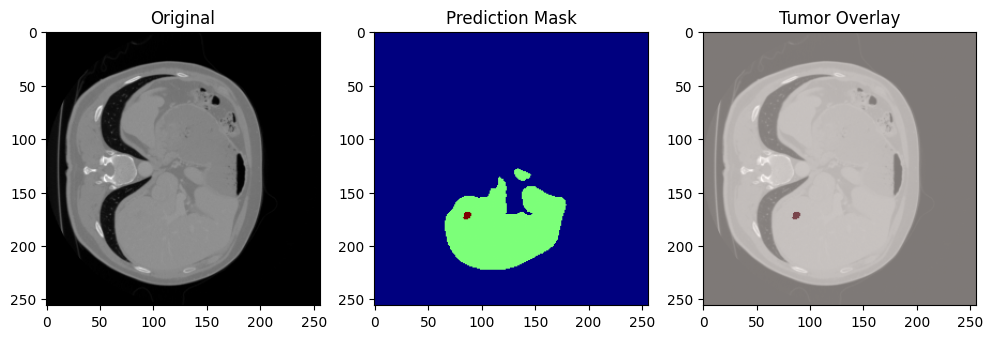

In [31]:
# Show result
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="jet")
plt.title("Prediction Mask")

plt.subplot(1,3,3)
plt.imshow(img, cmap="gray")
plt.imshow(mask==2, alpha=0.5, cmap="Reds")
plt.title("Tumor Overlay")

plt.show()

In [32]:
print(np.unique(mask))

[0 1 2]


In [33]:
with torch.no_grad():
    pred = model(input_img)

print(pred.shape)
print(pred.min().item(), pred.max().item())

torch.Size([1, 3, 256, 256])
-22.657957077026367 15.377365112304688


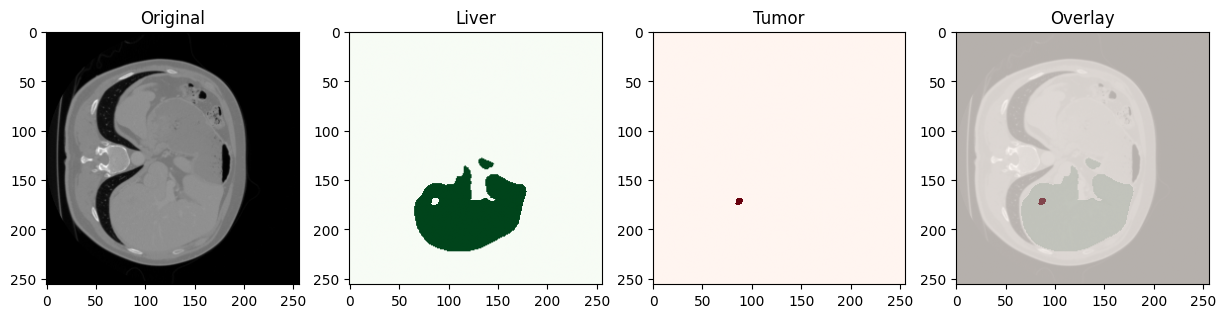

In [34]:
plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap="gray")
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(mask==1, cmap="Greens")
plt.title("Liver")

plt.subplot(1,4,3)
plt.imshow(mask==2, cmap="Reds")
plt.title("Tumor")

plt.subplot(1,4,4)
plt.imshow(img, cmap="gray")
plt.imshow(mask==1, alpha=0.3, cmap="Greens")
plt.imshow(mask==2, alpha=0.6, cmap="Reds")
plt.title("Overlay")

plt.show()

In [28]:
import os

files = os.listdir("../processed_data/val/images")

for f in files[:50]:
    img_path = "../processed_data/val/images/" + f

    img = cv2.imread(img_path, 0)
    img = cv2.resize(img, (256,256))

    x = img/255.0
    x = torch.tensor(x).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = model(x)

    m = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    vals = np.unique(m)

    if 2 in vals:
        print("Tumor found:", f, vals)

Tumor found: liver_34_100_0.png [0 1 2]
